In [3]:
!pip install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 25.8 MB/s eta 0:00:0000:0100:01


In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import plotly.express as px
import time
from sklearn.metrics.cluster import adjusted_rand_score

In [80]:
fn = '../../Subclustering/MNPO/SAM_RI_cleaned_MNPO_09082026.h5ad'
sam = SAM()
sam.load_data(fn)

In [79]:
sam_test = SAM()
sam_test.load_data('../../Active_SAM_joined/SAM_RI_joined_soupx_cleaned_01142026.h5ad')

In [81]:
sam_test.adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'leiden_clusters',
       'subclass_id_label_mapping', 'subclass_id_label_lc',
       'subclass_id_label_mapping_nounlabeled', 'subclass_id_label_crossed',
       'subclass_id_label_crossed_nn', 'subclass_lc', 'ss_subclass',
       'ss_subclass_nn', 'ss_subclass_nounlabeled_nn',
       'ss_subclass_crossed_nn', 'ss_subclass_nounlabeled_nn_agrp',
       'yanay_labels', 'yanay_label_nounlabeled', 'ss_subclass_old'],
      dtype='object')

In [82]:
tester = sam_test.adata.X[sam_test.adata.obs['ss_subclass'] == '116 AVPV-MEPO-SFO Tbr1 Glut']

In [83]:
tester

<432x23867 sparse matrix of type '<class 'numpy.float32'>'
	with 519679 stored elements in Compressed Sparse Row format>

In [84]:
sam.adata.X

<432x23867 sparse matrix of type '<class 'numpy.float32'>'
	with 519679 stored elements in Compressed Sparse Row format>

In [85]:
def csr_equal(A, B):
    if A.shape != B.shape:
        return False
    return (A != B).nnz == 0

In [86]:
csr_equal(tester,sam.adata.X)

True

In [87]:
org_two = 'ri'

In [88]:
clustering_param = {'mo':1,'cj':0.5,'ac':1.0,'ri':0.25}
sam.clustering(param =clustering_param[org_two])

In [89]:
sm_fn = '../../Subclustering/MNPO/sm_mg_'+org_two+'_MNPO_09082026.pkl'
sm = load_samap(sm_fn)

In [90]:
supertype_renaming = {'0519 AVPV-MEPO-SFO Tbr1 Glut_1':'MM_Foxp2_1',
                     '0521 AVPV-MEPO-SFO Tbr1 Glut_3':'MM_Thirst',
                     '0522 AVPV-MEPO-SFO Tbr1 Glut_4':'MM_Brs3',
                     '0520 AVPV-MEPO-SFO Tbr1 Glut_2':'MM_Warmth',
                     '0523 AVPV-MEPO-SFO Tbr1 Glut_5':'MM_Foxp2_2'}
renamed_supertype = [supertype_renaming[item] for item in sm.sams['mg'].adata.obs['supertype_id_label']]
sm.sams['mg'].adata.obs['eq_supertype'] = renamed_supertype

In [91]:
sm.sams[org_two].clustering(param =clustering_param[org_two])

In [92]:
sm.sams[org_two].adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'leiden_clusters',
       'subclass_id_label_mapping', 'subclass_id_label_lc',
       'subclass_id_label_mapping_nounlabeled', 'subclass_id_label_crossed',
       'subclass_id_label_crossed_nn', 'subclass_lc', 'ss_subclass',
       'ss_subclass_nn', 'ss_subclass_nounlabeled_nn',
       'ss_subclass_crossed_nn', 'ss_subclass_nounlabeled_nn_agrp',
       'yanay_labels', 'yanay_label_nounlabeled', 'ss_subclass_old',
       'eq_supertype', 'eq_clusters'],
      dtype='object')

In [93]:
sm.sams['mg'].adata.obs

,Unnamed: 0,cell_label,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,...,donor_sex,dataset_label,x,y,cluster_alias,subclass_id_label,supertype_id_label,class_id_label,leiden_clusters,eq_supertype
GGAATAATCCTGTACCL8TX_181019_01_D06,2420669,GGAATAATCCTGTACC-062_B01,GGAATAATCCTGTACC,062_B01,L8TX_181019_01_D06,WMB-10Xv2-HY,cell,NaN,10Xv2,HY,...,M,WMB-10Xv2,3.773273,0.253101,2250,116 AVPV-MEPO-SFO Tbr1 Glut,0519 AVPV-MEPO-SFO Tbr1 Glut_1,13 CNU-HYa Glut,9,MM_Foxp2_1
TGGCGCAGTACATGTCL8TX_181126_01_C11,2420730,TGGCGCAGTACATGTC-068_A01,TGGCGCAGTACATGTC,068_A01,L8TX_181126_01_C11,WMB-10Xv2-HY,cell,NaN,10Xv2,HY,...,F,WMB-10Xv2,4.656538,1.471239,2265,116 AVPV-MEPO-SFO Tbr1 Glut,0521 AVPV-MEPO-SFO Tbr1 Glut_3,13 CNU-HYa Glut,2,MM_Thirst
TAAACCGAGTACGATAL8TX_181126_01_C11,2487760,TAAACCGAGTACGATA-068_A01,TAAACCGAGTACGATA,068_A01,L8TX_181126_01_C11,WMB-10Xv2-HY,cell,NaN,10Xv2,HY,...,F,WMB-10Xv2,1.682782,-0.871892,2256,116 AVPV-MEPO-SFO Tbr1 Glut,0522 AVPV-MEPO-SFO Tbr1 Glut_4,13 CNU-HYa Glut,11,MM_Brs3
CATCAGACATCCCACTL8TX_181019_01_D06,2495119,CATCAGACATCCCACT-062_B01,CATCAGACATCCCACT,062_B01,L8TX_181019_01_D06,WMB-10Xv2-HY,cell,NaN,10Xv2,HY,...,M,WMB-10Xv2,3.264485,0.734875,2269,116 AVPV-MEPO-SFO Tbr1 Glut,0520 AVPV-MEPO-SFO Tbr1 Glut_2,13 CNU-HYa Glut,7,MM_Warmth
TAATTCCGTAGCGAGTL8TX_190614_01_B06,206692,TAATTCCGTAGCGAGT-126_B01,TAATTCCGTAGCGAGT,126_B01,L8TX_190614_01_B06,WMB-10Xv3-PAL,cell,NaN,10Xv3,PAL,...,M,WMB-10Xv3,3.068024,0.618359,2269,116 AVPV-MEPO-SFO Tbr1 Glut,0520 AVPV-MEPO-SFO Tbr1 Glut_2,13 CNU-HYa Glut,7,MM_Warmth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTAGGGTCAGGGAATCL8TX_200903_01_H11,221153,TTAGGGTCAGGGAATC-354_B06,TTAGGGTCAGGGAATC,354_B06,L8TX_200903_01_H11,WMB-10Xv3-HY,cell,NaN,10Xv3,HY,...,F,WMB-10Xv3,3.471811,-0.450682,2291,116 AVPV-MEPO-SFO Tbr1 Glut,0522 AVPV-MEPO-SFO Tbr1 Glut_4,13 CNU-HYa Glut,19,MM_Brs3
TTCCAATAGTACGAGCL8TX_201016_01_E04,221154,TTCCAATAGTACGAGC-392_B04,TTCCAATAGTACGAGC,392_B04,L8TX_201016_01_E04,WMB-10Xv3-HY,cell,NaN,10Xv3,HY,...,M,WMB-10Xv3,3.353083,-0.485385,2291,116 AVPV-MEPO-SFO Tbr1 Glut,0522 AVPV-MEPO-SFO Tbr1 Glut_4,13 CNU-HYa Glut,11,MM_Brs3
TTGGGATGTAATGTGAL8TX_201015_01_B03,221155,TTGGGATGTAATGTGA-392_A04,TTGGGATGTAATGTGA,392_A04,L8TX_201015_01_B03,WMB-10Xv3-HY,cell,NaN,10Xv3,HY,...,M,WMB-10Xv3,3.420946,-0.512288,2291,116 AVPV-MEPO-SFO Tbr1 Glut,0522 AVPV-MEPO-SFO Tbr1 Glut_4,13 CNU-HYa Glut,11,MM_Brs3
CACAGTAGTTGCGCACL8TX_190423_01_B07,2542986,CACAGTAGTTGCGCAC-113_B01,CACAGTAGTTGCGCAC,113_B01,L8TX_190423_01_B07,WMB-10Xv2-OLF,cell,NaN,10Xv2,OLF,...,M,WMB-10Xv2,5.303107,-0.692607,2254,116 AVPV-MEPO-SFO Tbr1 Glut,0519 AVPV-MEPO-SFO Tbr1 Glut_1,13 CNU-HYa Glut,17,MM_Foxp2_1


In [94]:
keys = {'mg':'eq_supertype',org_two:'leiden_clusters'}
D,MappingTable = get_mapping_scores(sm,keys)

lim_MappingTable = MappingTable.filter(like='mg_')
lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(org_two + '_')]

In [95]:
lim_MappingTable

,mg_MM_Brs3,mg_MM_Foxp2_1,mg_MM_Foxp2_2,mg_MM_Thirst,mg_MM_Warmth
ri_0,0.017831,0.011906,0.117076,0.514138,0.082049
ri_1,0.411517,0.345500,0.001982,0.041992,0.133492
ri_2,0.012978,0.503567,0.145485,0.044341,0.023164
ri_3,0.008989,0.000000,0.000000,0.000000,0.839643
ri_4,0.376332,0.003592,0.000235,0.007077,0.077579


In [96]:
csr_equal(sam.adata.X,sm.sams[org_two].adata.X)

True

In [97]:
sm.sams['mg'].adata.obs

,Unnamed: 0,cell_label,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,...,donor_sex,dataset_label,x,y,cluster_alias,subclass_id_label,supertype_id_label,class_id_label,leiden_clusters,eq_supertype
GGAATAATCCTGTACCL8TX_181019_01_D06,2420669,GGAATAATCCTGTACC-062_B01,GGAATAATCCTGTACC,062_B01,L8TX_181019_01_D06,WMB-10Xv2-HY,cell,NaN,10Xv2,HY,...,M,WMB-10Xv2,3.773273,0.253101,2250,116 AVPV-MEPO-SFO Tbr1 Glut,0519 AVPV-MEPO-SFO Tbr1 Glut_1,13 CNU-HYa Glut,9,MM_Foxp2_1
TGGCGCAGTACATGTCL8TX_181126_01_C11,2420730,TGGCGCAGTACATGTC-068_A01,TGGCGCAGTACATGTC,068_A01,L8TX_181126_01_C11,WMB-10Xv2-HY,cell,NaN,10Xv2,HY,...,F,WMB-10Xv2,4.656538,1.471239,2265,116 AVPV-MEPO-SFO Tbr1 Glut,0521 AVPV-MEPO-SFO Tbr1 Glut_3,13 CNU-HYa Glut,2,MM_Thirst
TAAACCGAGTACGATAL8TX_181126_01_C11,2487760,TAAACCGAGTACGATA-068_A01,TAAACCGAGTACGATA,068_A01,L8TX_181126_01_C11,WMB-10Xv2-HY,cell,NaN,10Xv2,HY,...,F,WMB-10Xv2,1.682782,-0.871892,2256,116 AVPV-MEPO-SFO Tbr1 Glut,0522 AVPV-MEPO-SFO Tbr1 Glut_4,13 CNU-HYa Glut,11,MM_Brs3
CATCAGACATCCCACTL8TX_181019_01_D06,2495119,CATCAGACATCCCACT-062_B01,CATCAGACATCCCACT,062_B01,L8TX_181019_01_D06,WMB-10Xv2-HY,cell,NaN,10Xv2,HY,...,M,WMB-10Xv2,3.264485,0.734875,2269,116 AVPV-MEPO-SFO Tbr1 Glut,0520 AVPV-MEPO-SFO Tbr1 Glut_2,13 CNU-HYa Glut,7,MM_Warmth
TAATTCCGTAGCGAGTL8TX_190614_01_B06,206692,TAATTCCGTAGCGAGT-126_B01,TAATTCCGTAGCGAGT,126_B01,L8TX_190614_01_B06,WMB-10Xv3-PAL,cell,NaN,10Xv3,PAL,...,M,WMB-10Xv3,3.068024,0.618359,2269,116 AVPV-MEPO-SFO Tbr1 Glut,0520 AVPV-MEPO-SFO Tbr1 Glut_2,13 CNU-HYa Glut,7,MM_Warmth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTAGGGTCAGGGAATCL8TX_200903_01_H11,221153,TTAGGGTCAGGGAATC-354_B06,TTAGGGTCAGGGAATC,354_B06,L8TX_200903_01_H11,WMB-10Xv3-HY,cell,NaN,10Xv3,HY,...,F,WMB-10Xv3,3.471811,-0.450682,2291,116 AVPV-MEPO-SFO Tbr1 Glut,0522 AVPV-MEPO-SFO Tbr1 Glut_4,13 CNU-HYa Glut,19,MM_Brs3
TTCCAATAGTACGAGCL8TX_201016_01_E04,221154,TTCCAATAGTACGAGC-392_B04,TTCCAATAGTACGAGC,392_B04,L8TX_201016_01_E04,WMB-10Xv3-HY,cell,NaN,10Xv3,HY,...,M,WMB-10Xv3,3.353083,-0.485385,2291,116 AVPV-MEPO-SFO Tbr1 Glut,0522 AVPV-MEPO-SFO Tbr1 Glut_4,13 CNU-HYa Glut,11,MM_Brs3
TTGGGATGTAATGTGAL8TX_201015_01_B03,221155,TTGGGATGTAATGTGA-392_A04,TTGGGATGTAATGTGA,392_A04,L8TX_201015_01_B03,WMB-10Xv3-HY,cell,NaN,10Xv3,HY,...,M,WMB-10Xv3,3.420946,-0.512288,2291,116 AVPV-MEPO-SFO Tbr1 Glut,0522 AVPV-MEPO-SFO Tbr1 Glut_4,13 CNU-HYa Glut,11,MM_Brs3
CACAGTAGTTGCGCACL8TX_190423_01_B07,2542986,CACAGTAGTTGCGCAC-113_B01,CACAGTAGTTGCGCAC,113_B01,L8TX_190423_01_B07,WMB-10Xv2-OLF,cell,NaN,10Xv2,OLF,...,M,WMB-10Xv2,5.303107,-0.692607,2254,116 AVPV-MEPO-SFO Tbr1 Glut,0519 AVPV-MEPO-SFO Tbr1 Glut_1,13 CNU-HYa Glut,17,MM_Foxp2_1


In [98]:
fin_mapping = {}
for item in lim_MappingTable.index:
    bm = lim_MappingTable.loc[item,:].idxmax()
    if lim_MappingTable.loc[item,bm] > .2:
        fin_mapping[item] = bm
    else:
        fin_mapping[item] = item
        
fin_labels = []
for item in sm.sams[org_two].adata.obs['leiden_clusters']:
    fin_labels.append(fin_mapping[org_two + '_' + str(item)][3:])

In [99]:
sam.adata.obs['fin_test'] = fin_labels

In [25]:
mg_genes = ['Etv1','Onecut1','Bcl11a','Foxp2','Ebf1','Emx2','Adcyap1','Agtr1a','Rxfp1','Crh','Trpc3','Sncg', 'Opn5','Rxfp2','Npy','Brs3','Ucn3','Slc2a9']
mo_genes = ['Etv1','Onecut1','Bcl11a','Foxp2','Ebf1','Emx2','Adcyap1','ENSMOCG00000019499','Rxfp1','Crh','Trpc3','Sncg', 'Opn5','Rxfp2','Npy','Brs3','UCN3','Slc2a9']
cj_genes = ['ETV1','ONECUT1','BCL11A','FOXP2','EBF1','EMX2','ADCYAP1','AGTR1','RXFP1','CRH','TRPC3','SNCG','OPN5','ENSCJPG00005003031','NPY','BRS3','SLC2A9']
ac_genes = ['etv1','bcl11a','ebf1','emx2','adcyap1','rxfp1','crh','trpc3','sncg','LOC100554017','LOC100553533','npy','brs3','ucn3','slc2a9']
ri_genes = ['LOC138641708','ONECUT1','BCL11A','FOXP2','EBF1','EMX2','ADCYAP1','LOC138638365','RXFP1','CRH','TRPC3','SNCG', 'OPN5','RXFP2','NPY','BRS3','UCN3','SLC2A9']

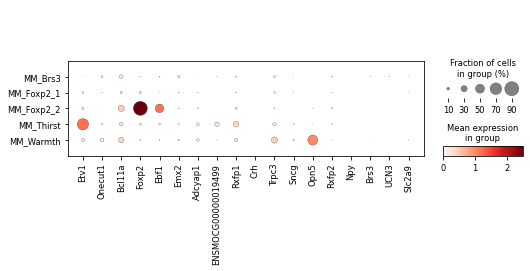

In [26]:
sc.pl.dotplot(sam.adata,groupby = 'fin_test',var_names=mo_genes)

In [100]:
sam.adata.obs['fin_test'] = sam.adata.obs['fin_test'].astype('category')

In [101]:
sam.adata.obs['fin_test'].equals(sam.adata.obs['eq_supertype'])

True

In [27]:
fin_labels = []
for item in sm.sams[org_two].adata.obs['leiden_clusters']:
    fin_labels.append(fin_mapping[org_two + '_' + str(item)][3:])

In [27]:
sam.adata.obs['eq_supertype'] = fin_labels
sm.sams[org_two].adata.obs['eq_supertype'] = fin_labels

In [28]:
sam.adata.obs['eq_clusters'] = sm.sams[org_two].adata.obs['leiden_clusters']
sm.sams[org_two].adata.obs['eq_clusters'] = sm.sams[org_two].adata.obs['leiden_clusters']

In [29]:
sam.save_anndata(fn)

In [30]:
save_samap(sm,sm_fn)